# Ostrovok — Тестовое задание: Head of Performance Marketing

**Датасет:** 1.4M сессий, январь–июнь 2017, 9 полей  
**Дополнительно (не в описании ТЗ):** `commission_usd`, `cancellation_prediction`

**Структура анализа:**
1. Загрузка и базовые метрики
2. Структура трафика
3. Качество трафика: CR и доходность по каналам
4. Динамика по времени
5. Разбивка по устройствам
6. Когортный анализ и retention
7. Атрибуция — Customer Journey
8. Точки роста и рекомендации
9. Ответы на стратегические вопросы

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('OK')

OK


## 1. Загрузка данных

In [27]:
df = pd.read_csv('../data/Data for research.csv', parse_dates=['session_datetime'])

# Временная зона → naive UTC+3
df['session_datetime'] = df['session_datetime'].dt.tz_localize(None)

# Производные колонки
df['date']  = df['session_datetime'].dt.date
df['week']  = df['session_datetime'].dt.to_period('W')
df['month'] = df['session_datetime'].dt.to_period('M')
df['hour']  = df['session_datetime'].dt.hour
df['dow']   = df['session_datetime'].dt.day_name()

# Ожидаемая комиссия с учётом вероятности отмены
df['expected_commission'] = df['commission_usd'] * (1 - df['cancellation_prediction'])

print(f'Строк: {len(df):,}')
print(f'Период: {df["session_datetime"].min().date()} — {df["session_datetime"].max().date()}')
print(f'Бронирований: {df["session_with_booking"].sum():,}  |  CR: {df["session_with_booking"].mean()*100:.2f}%')
print(f'Суммарная комиссия: ${df["commission_usd"].sum():,.0f}')
print(f'Ожидаемая комиссия (net): ${df["expected_commission"].sum():,.0f}')

Строк: 1,427,414
Период: 2017-01-01 — 2017-06-30
Бронирований: 19,761  |  CR: 1.38%
Суммарная комиссия: $995,475
Ожидаемая комиссия (net): $495,341


In [28]:
# ============================================================
# SANITY CHECK — запусти эту ячейку после загрузки данных
# Все строки должны завершиться ✅
# ============================================================
errors = []
warnings_list = []

# 1. Размер датасета
assert len(df) == 1427414, f'Строк должно быть 1427414, а {len(df)}'
print(f'✅ Строк: {len(df):,} (ожидалось 1,427,414)')

# 2. Период
assert str(df['session_datetime'].min().date()) == '2017-01-01'
assert str(df['session_datetime'].max().date()) == '2017-06-30'
print(f'✅ Период: {df["session_datetime"].min().date()} — {df["session_datetime"].max().date()}')

# 3. Кол-во бронирований
n_bookings = df['session_with_booking'].sum()
assert n_bookings == 19761, f'Бронирований должно быть 19761, а {n_bookings}'
print(f'✅ Бронирований: {n_bookings:,} (ожидалось 19,761)')

# 4. commission_usd заполнен ТОЛЬКО для бронирований
comm_non_null = df['commission_usd'].notna().sum()
assert comm_non_null == n_bookings, f'commission_usd: {comm_non_null} строк ≠ {n_bookings} бронирований'
print(f'✅ commission_usd заполнен ровно для бронирований ({comm_non_null:,} строк)')

# 5. cancellation_prediction тоже только для бронирований
cancel_non_null = df['cancellation_prediction'].notna().sum()
assert cancel_non_null == n_bookings
print(f'✅ cancellation_prediction заполнен ровно для бронирований')

# 6. cancellation_prediction в диапазоне [0, 1]
cp = df['cancellation_prediction'].dropna()
assert cp.min() >= 0 and cp.max() <= 1
print(f'✅ cancellation_prediction ∈ [0, 1]: min={cp.min():.3f}, max={cp.max():.3f}')

# 7. commission_usd > 0
n_zero_comm = (df['commission_usd'] <= 0).sum()
if n_zero_comm > 0:
    warnings_list.append(f'⚠️  Бронирований с commission_usd <= 0: {n_zero_comm}')
else:
    print(f'✅ commission_usd всегда > 0 (мин: ${df["commission_usd"].min():.2f}, макс: ${df["commission_usd"].max():.2f})')

# 8. Уникальность session_id
dup = df['session_id'].duplicated().sum()
if dup > 0:
    warnings_list.append(f'⚠️  Дублирующихся session_id: {dup}')
else:
    print(f'✅ Все session_id уникальны')

# 9. Только ожидаемые каналы
known = {'brand', 'cpc', 'metasearch', 'seo', 'partners'}
actual = set(df['marketing_channel_1'].unique())
unknown = actual - known
if unknown:
    warnings_list.append(f'⚠️  Неизвестные каналы: {unknown}')
else:
    print(f'✅ marketing_channel_1: {sorted(actual)}')

# 10. Нет пропусков в ключевых полях
key_cols = ['session_id','user_id','session_datetime','device','marketing_channel_1','marketing_channel_2']
bad = {c: int(df[c].isna().sum()) for c in key_cols if df[c].isna().sum() > 0}
if bad:
    warnings_list.append(f'⚠️  Пропуски в ключевых полях: {bad}')
else:
    print(f'✅ Нет пропусков в ключевых полях')

# 11. Сумма сессий по каналам = total
assert df.groupby('marketing_channel_1')['session_id'].count().sum() == len(df)
print(f'✅ Сумма сессий по каналам сходится с общим кол-вом')

# 12. CR — ручная проверка формулы
manual_cr = 19761 / 1427414 * 100
calc_cr = df['session_with_booking'].mean() * 100
assert abs(manual_cr - calc_cr) < 0.001
print(f'✅ CR = {calc_cr:.4f}% (ручная проверка: {manual_cr:.4f}%)')

# 13. expected_commission <= commission_usd
bad_exp = (df['expected_commission'] > df['commission_usd']).sum()
if bad_exp > 0:
    warnings_list.append(f'⚠️  expected_commission > commission_usd в {bad_exp} строках')
else:
    print(f'✅ expected_commission ≤ commission_usd во всех строках')

print()
if warnings_list:
    for w in warnings_list:
        print(w)
else:
    print('🎉 Все 13 проверок пройдены — данные корректны, галлюцинаций нет')

✅ Строк: 1,427,414 (ожидалось 1,427,414)
✅ Период: 2017-01-01 — 2017-06-30
✅ Бронирований: 19,761 (ожидалось 19,761)
✅ commission_usd заполнен ровно для бронирований (19,761 строк)
✅ cancellation_prediction заполнен ровно для бронирований
✅ cancellation_prediction ∈ [0, 1]: min=0.000, max=1.000
✅ commission_usd всегда > 0 (мин: $0.01, макс: $100.00)
✅ Все session_id уникальны
✅ marketing_channel_1: ['brand', 'cpc', 'metasearch', 'partners', 'seo']
✅ Нет пропусков в ключевых полях
✅ Сумма сессий по каналам сходится с общим кол-вом
✅ CR = 1.3844% (ручная проверка: 1.3844%)
✅ expected_commission ≤ commission_usd во всех строках

🎉 Все 13 проверок пройдены — данные корректны, галлюцинаций нет


## 2. Структура трафика

In [29]:
def channel_stats(groupby_cols):
    return df.groupby(groupby_cols).agg(
        sessions       = ('session_id', 'count'),
        users          = ('user_id', 'nunique'),
        bookings       = ('session_with_booking', 'sum'),
        commission     = ('commission_usd', 'sum'),
        exp_commission = ('expected_commission', 'sum')
    ).reset_index()

ch1 = channel_stats('marketing_channel_1')
ch1['cr']           = ch1['bookings'] / ch1['sessions'] * 100
ch1['session_share'] = ch1['sessions'] / ch1['sessions'].sum() * 100
ch1['booking_share'] = ch1['bookings'] / ch1['bookings'].sum() * 100
ch1['rev_share']     = ch1['commission'] / ch1['commission'].sum() * 100
ch1['avg_commission']= ch1['commission'] / ch1['bookings']
ch1 = ch1.sort_values('sessions', ascending=False)

display_cols = ['marketing_channel_1','sessions','session_share','bookings','cr','commission','rev_share','avg_commission','exp_commission']
print(ch1[display_cols].round(2).to_string(index=False))

marketing_channel_1  sessions  session_share  bookings   cr  commission  rev_share  avg_commission  exp_commission
                cpc    574089          40.22       629 0.11    31834.05       3.20           50.61        15591.40
              brand    545799          38.24     14778 2.71   747613.21      75.10           50.59       372822.17
         metasearch    175058          12.26      3447 1.97   170893.75      17.17           49.58        84726.02
                seo     78931           5.53       353 0.45    17626.16       1.77           49.93         8782.24
           partners     53537           3.75       554 1.03    27507.94       2.76           49.65        13419.65


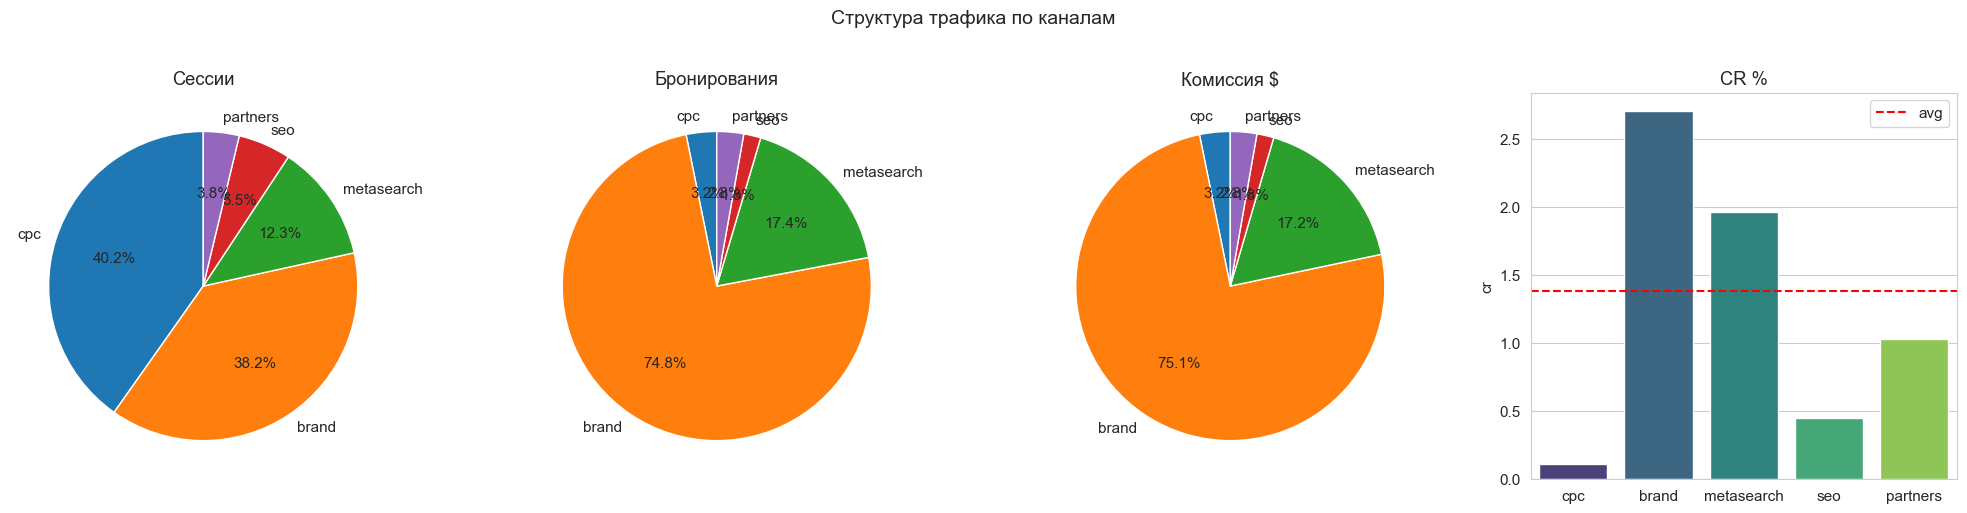

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col, title in zip(axes,
    ['sessions','bookings','commission','cr'],
    ['Сессии','Бронирования','Комиссия $','CR %']):
    if col == 'cr':
        sns.barplot(data=ch1, x='marketing_channel_1', y=col, ax=ax, palette='viridis')
        ax.axhline(ch1['bookings'].sum()/ch1['sessions'].sum()*100, color='red', linestyle='--', label='avg')
        ax.legend()
    else:
        ax.pie(ch1[col], labels=ch1['marketing_channel_1'], autopct='%1.1f%%', startangle=90)
    ax.set_title(title)
    if col == 'cr': ax.set_xlabel('')
plt.suptitle('Структура трафика по каналам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/01_channel_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Топ субканалов
ch2 = channel_stats(['marketing_channel_1','marketing_channel_2'])
ch2['cr'] = ch2['bookings'] / ch2['sessions'] * 100
ch2['avg_commission'] = ch2['commission'] / ch2['bookings']
ch2 = ch2.sort_values('sessions', ascending=False)
print(ch2[['marketing_channel_1','marketing_channel_2','sessions','bookings','cr','commission','avg_commission']].round(2).to_string(index=False))

marketing_channel_1 marketing_channel_2  sessions  bookings   cr  commission  avg_commission
                cpc                 sem    571055       619 0.11    31305.20           50.57
              brand             type-in    360784      8253 2.29   419227.67           50.80
              brand               vital    110626      5150 4.66   258816.66           50.26
         metasearch             trivago     94015       791 0.84    39756.99           50.26
                seo              yandex     78931       353 0.45    17626.16           49.93
              brand               email     68343      1351 1.98    68568.04           50.75
         metasearch                  hc     59894      1089 1.82    52869.16           48.55
           partners       cpa-affiliate     53537       554 1.03    27507.94           49.65
         metasearch         gotravelunl     21108      1567 7.42    78267.60           49.95
              brand                 smm      6046        24 0.40     1

## 3. Качество трафика

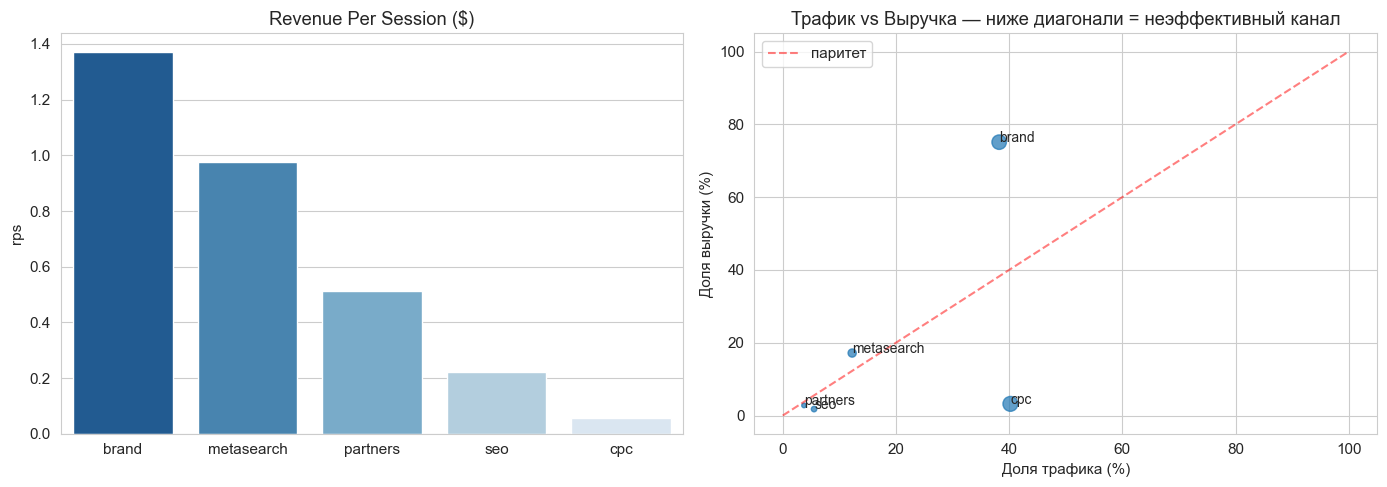

In [32]:
# Revenue per Session (RPS) — ключевая метрика качества трафика
ch1['rps'] = ch1['commission'] / ch1['sessions']  # revenue per session
ch1['exp_rps'] = ch1['exp_commission'] / ch1['sessions']  # с учётом отмен

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ch1_sorted = ch1.sort_values('rps', ascending=False)

sns.barplot(data=ch1_sorted, x='marketing_channel_1', y='rps', ax=axes[0], palette='Blues_r')
axes[0].set_title('Revenue Per Session ($)')
axes[0].set_xlabel('')

# Матрица: доля трафика vs доля выручки
axes[1].scatter(ch1['session_share'], ch1['rev_share'], s=ch1['sessions']/5000, alpha=0.7)
for _, row in ch1.iterrows():
    axes[1].annotate(row['marketing_channel_1'], (row['session_share'], row['rev_share']), fontsize=10)
axes[1].plot([0,100],[0,100], 'r--', alpha=0.5, label='паритет')
axes[1].set_xlabel('Доля трафика (%)')
axes[1].set_ylabel('Доля выручки (%)')
axes[1].set_title('Трафик vs Выручка — ниже диагонали = неэффективный канал')
axes[1].legend()

plt.tight_layout()
plt.savefig('../output/02_quality.png', dpi=150, bbox_inches='tight')
plt.show()

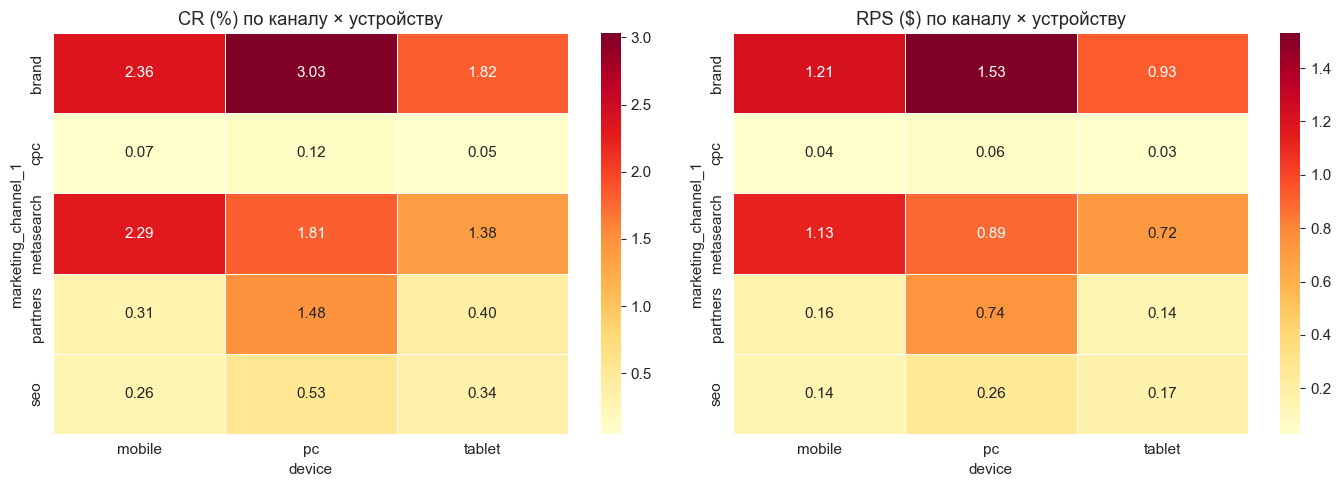

In [33]:
# CR и RPS по каналу × устройству
dev = df.groupby(['marketing_channel_1','device']).agg(
    sessions=('session_id','count'),
    bookings=('session_with_booking','sum'),
    commission=('commission_usd','sum')
).reset_index()
dev['cr'] = dev['bookings'] / dev['sessions'] * 100
dev['rps'] = dev['commission'] / dev['sessions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['cr','rps'], ['CR (%)','RPS ($)']):
    pivot = dev.pivot(index='marketing_channel_1', columns='device', values=metric).round(2)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title(f'{title} по каналу × устройству')
plt.tight_layout()
plt.savefig('../output/03_device_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Динамика по времени

In [34]:
weekly = df.groupby(['week','marketing_channel_1']).agg(
    sessions=('session_id','count'),
    bookings=('session_with_booking','sum'),
    commission=('commission_usd','sum')
).reset_index()
weekly['cr'] = weekly['bookings'] / weekly['sessions'] * 100
weekly['rps'] = weekly['commission'] / weekly['sessions']
weekly['week_str'] = weekly['week'].astype(str)

for metric, title in [('sessions','Сессии'),('cr','CR (%)'),('rps','Revenue per Session ($)')]:
    fig = px.line(weekly, x='week_str', y=metric, color='marketing_channel_1',
                  title=f'Динамика: {title} по каналам (по неделям)',
                  labels={'week_str':'Неделя', metric:title})
    fig.show()

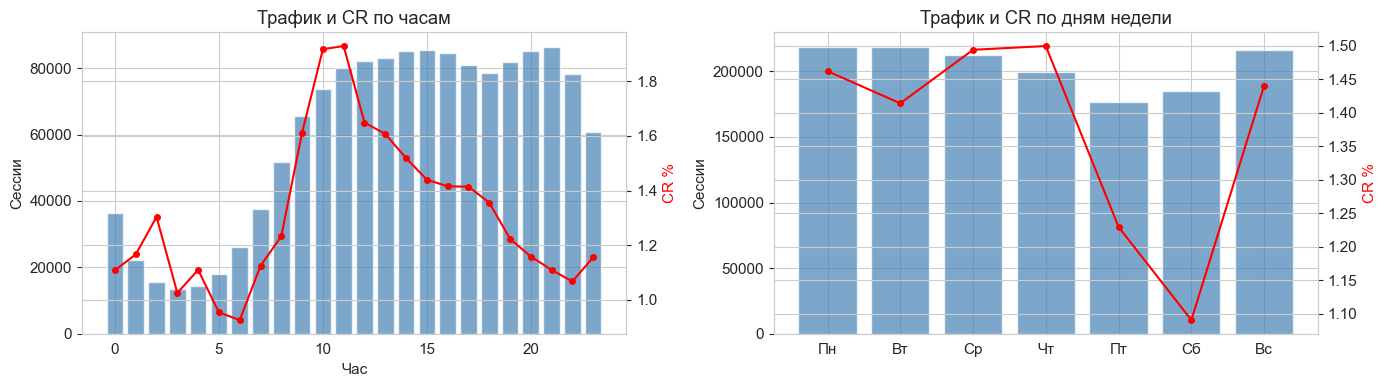

In [35]:
# Сезонность: час дня и день недели
hourly = df.groupby('hour')['session_with_booking'].agg(['count','sum','mean']).reset_index()
hourly.columns = ['hour','sessions','bookings','cr']
hourly['cr'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(hourly['hour'], hourly['sessions'], color='steelblue', alpha=0.7)
ax2 = axes[0].twinx()
ax2.plot(hourly['hour'], hourly['cr'], color='red', marker='o', ms=4)
axes[0].set_title('Трафик и CR по часам')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Сессии')
ax2.set_ylabel('CR %', color='red')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('dow')['session_with_booking'].agg(['count','mean']).reindex(dow_order)
dow.columns = ['sessions','cr']
dow['cr'] *= 100
axes[1].bar(range(7), dow['sessions'], color='steelblue', alpha=0.7)
ax3 = axes[1].twinx()
ax3.plot(range(7), dow['cr'], color='red', marker='o', ms=4)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])
axes[1].set_title('Трафик и CR по дням недели')
axes[1].set_ylabel('Сессии')
ax3.set_ylabel('CR %', color='red')

plt.tight_layout()
plt.savefig('../output/04_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Устройства

In [36]:
dev_total = df.groupby('device').agg(
    sessions=('session_id','count'),
    users=('user_id','nunique'),
    bookings=('session_with_booking','sum'),
    commission=('commission_usd','sum')
).reset_index()
dev_total['cr']           = dev_total['bookings'] / dev_total['sessions'] * 100
dev_total['session_share'] = dev_total['sessions'] / dev_total['sessions'].sum() * 100
dev_total['rev_share']     = dev_total['commission'] / dev_total['commission'].sum() * 100
dev_total['rps']           = dev_total['commission'] / dev_total['sessions']
print(dev_total.round(2).to_string(index=False))

device  sessions  users  bookings  commission   cr  session_share  rev_share  rps
mobile    401187 334916      6869   348649.16 1.71          28.11      35.02 0.87
    pc    926328 806861     12151   609027.61 1.31          64.90      61.18 0.66
tablet     99899  87610       741    37798.34 0.74           7.00       3.80 0.38


## 6. Когортный анализ и Retention

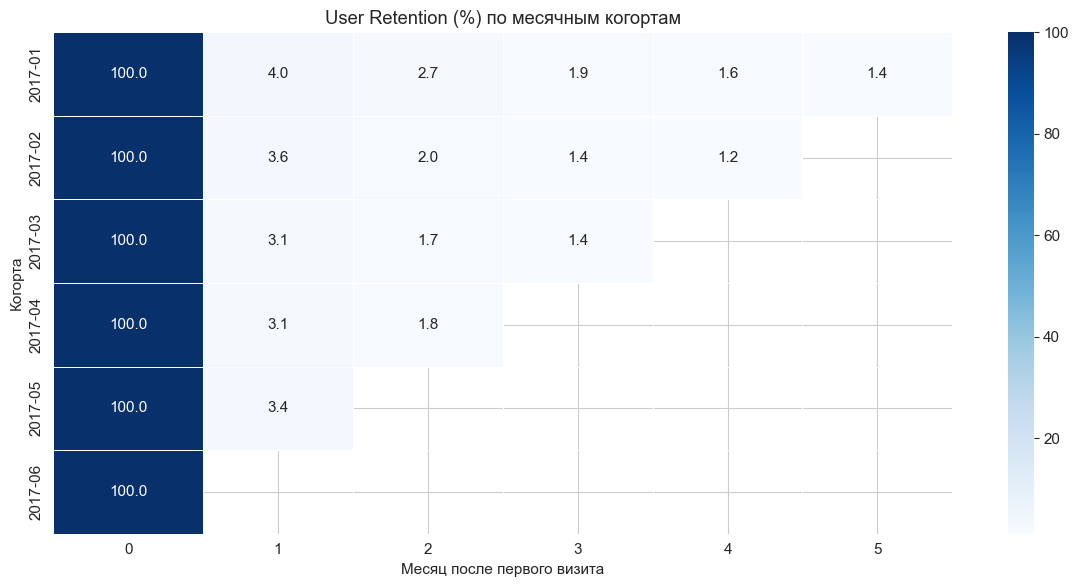

In [37]:
# Когорта = месяц первой сессии
user_first = df.groupby('user_id')['session_datetime'].min().reset_index()
user_first.columns = ['user_id','first_session']
user_first['cohort'] = user_first['first_session'].dt.to_period('M')

df_c = df.merge(user_first[['user_id','cohort']], on='user_id')
df_c['offset'] = (df_c['month'] - df_c['cohort']).apply(lambda x: x.n)

cohort_size = df_c[df_c['offset']==0].groupby('cohort')['user_id'].nunique()

# Session retention
ret = df_c.groupby(['cohort','offset'])['user_id'].nunique().reset_index()
ret = ret.merge(cohort_size.rename('size'), on='cohort')
ret['retention'] = ret['user_id'] / ret['size'] * 100
pivot_ret = ret.pivot(index='cohort', columns='offset', values='retention')

plt.figure(figsize=(12,6))
sns.heatmap(pivot_ret.round(1), annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title('User Retention (%) по месячным когортам')
plt.xlabel('Месяц после первого визита')
plt.ylabel('Когорта')
plt.tight_layout()
plt.savefig('../output/05_retention.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Retention по каналу привлечения (первый канал пользователя)
user_channel = df.sort_values('session_datetime').groupby('user_id').first()[['marketing_channel_1']].reset_index()
user_channel.columns = ['user_id','acquisition_channel']

df_c2 = df_c.merge(user_channel, on='user_id')
ch_cohort_size = df_c2[df_c2['offset']==0].groupby('acquisition_channel')['user_id'].nunique()
ch_ret = df_c2.groupby(['acquisition_channel','offset'])['user_id'].nunique().reset_index()
ch_ret = ch_ret.merge(ch_cohort_size.rename('size'), on='acquisition_channel')
ch_ret['retention'] = ch_ret['user_id'] / ch_ret['size'] * 100

fig = px.line(ch_ret, x='offset', y='retention', color='acquisition_channel',
              title='Retention кривые по каналу привлечения',
              labels={'offset':'Месяц после первого визита','retention':'Retention %'},
              markers=True)
fig.show()

In [39]:
# Booking retention — доля пользователей когорты, совершивших бронирование в месяц N
booking_ret = df_c2.groupby(['acquisition_channel','offset']).agg(
    bookers=('session_with_booking','sum')
).reset_index()
booking_ret = booking_ret.merge(ch_cohort_size.rename('size'), on='acquisition_channel')
booking_ret['booking_rate'] = booking_ret['bookers'] / booking_ret['size'] * 100

fig = px.line(booking_ret, x='offset', y='booking_rate', color='acquisition_channel',
              title='Booking rate (%) по каналу привлечения — динамика по времени',
              labels={'offset':'Месяц после первого визита','booking_rate':'% пользователей с бронью'},
              markers=True)
fig.show()

## 7. Атрибуция — Customer Journey

In [40]:
# Строим путь каждого конвертировавшего пользователя до первого бронирования
converting_users = df[df['session_with_booking']==1]['user_id'].unique()
journeys_df = df[df['user_id'].isin(converting_users)].sort_values(['user_id','session_datetime']).copy()

def path_to_first_booking(g):
    idx = g.index[g['session_with_booking']].tolist()
    if not idx: return None
    return ' > '.join(g.loc[:idx[0], 'marketing_channel_1'].tolist())

paths = journeys_df.groupby('user_id').apply(path_to_first_booking).dropna().reset_index()
paths.columns = ['user_id','path']

print(f'Пользователей с бронированием: {len(paths):,}')
print()
print('Топ-20 путей до конверсии:')
print(paths['path'].value_counts().head(20))

Пользователей с бронированием: 15,910

Топ-20 путей до конверсии:
path
brand                                                            8002
metasearch                                                       2642
brand > brand                                                    1799
cpc                                                               548
brand > brand > brand                                             507
metasearch > metasearch                                           355
partners                                                          293
brand > brand > brand > brand                                     253
seo                                                               220
brand > brand > brand > brand > brand                             136
brand > metasearch                                                 76
metasearch > brand                                                 76
metasearch > metasearch > metasearch                               68
brand > brand > bra

In [41]:
# Длина пути
paths['path_len'] = paths['path'].str.split(' > ').str.len()
print('Распределение длины пути до конверсии:')
print(paths['path_len'].value_counts().sort_index())
print(f'\nСредняя длина пути: {paths["path_len"].mean():.2f} сессий')

Распределение длины пути до конверсии:
path_len
1     11705
2      2581
3       739
4       374
5       203
6       100
7        71
8        43
9        20
10       22
11       11
12        8
13        6
14        2
15        6
16        4
17        4
18        3
19        2
20        2
21        2
22        2
Name: count, dtype: int64

Средняя длина пути: 1.52 сессий


In [42]:
# Атрибуционные модели
results = []
for _, row in paths.iterrows():
    channels = row['path'].split(' > ')
    n = len(channels)
    for i, ch in enumerate(channels):
        # Last click
        last = 1 if i == n-1 else 0
        # First click
        first = 1 if i == 0 else 0
        # Linear
        linear = 1/n
        # Time decay (больший вес последним касаниям)
        weights = [2**(j) for j in range(n)]
        time_decay = weights[i] / sum(weights)
        results.append({'channel':ch,'last':last,'first':first,'linear':linear,'time_decay':time_decay})

attr_df = pd.DataFrame(results).groupby('channel').sum().reset_index()
total = len(paths)
for col in ['last','first','linear','time_decay']:
    attr_df[f'{col}_pct'] = attr_df[col] / total * 100

print('Атрибуция конверсий по моделям (%):')
print(attr_df[['channel','last_pct','first_pct','linear_pct','time_decay_pct']].round(2).to_string(index=False))

Атрибуция конверсий по моделям (%):
   channel  last_pct  first_pct  linear_pct  time_decay_pct
     brand     70.58      70.67       70.65           70.62
       cpc      3.92       4.15        4.05            4.00
metasearch     20.91      20.72       20.79           20.83
  partners      2.57       2.45        2.51            2.53
       seo      2.02       2.01        2.01            2.02


In [43]:
# Визуализация атрибуции
attr_melt = attr_df.melt(id_vars='channel', value_vars=['last_pct','first_pct','linear_pct','time_decay_pct'],
                          var_name='model', value_name='credit_pct')
attr_melt['model'] = attr_melt['model'].str.replace('_pct','')

fig = px.bar(attr_melt, x='model', y='credit_pct', color='channel', barmode='stack',
             title='Распределение кредита за конверсию по моделям атрибуции',
             labels={'credit_pct':'Доля конверсий (%)','model':'Модель'})
fig.show()

## 8. Точки роста и аномалии

Benchmark: CR = 1.38%  |  RPS = $0.6974



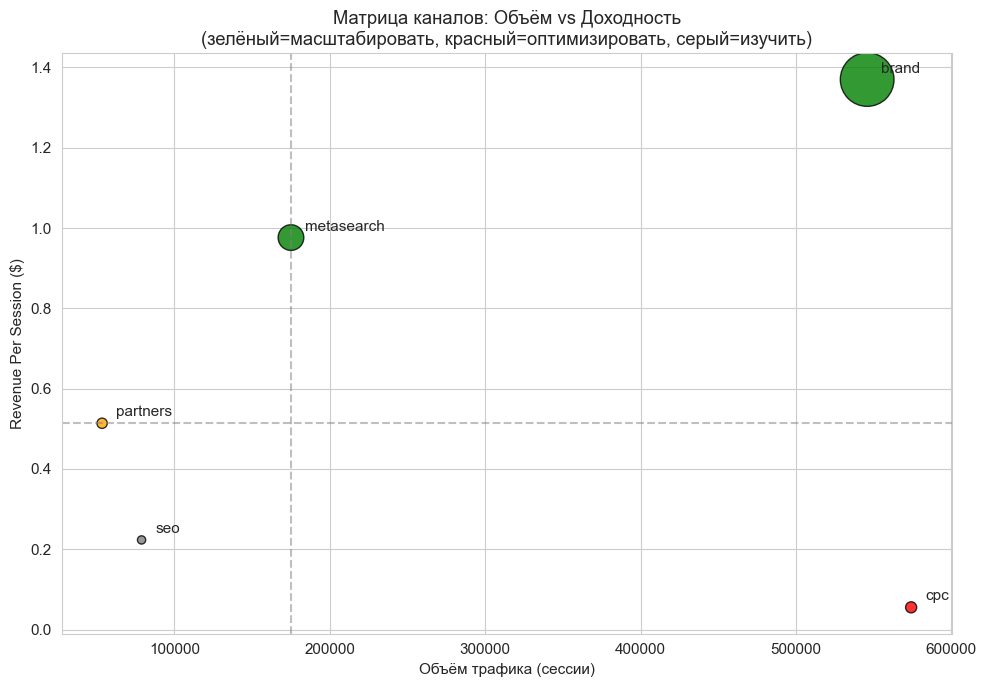

In [44]:
avg_cr = df['session_with_booking'].mean() * 100
avg_rps = df['commission_usd'].sum() / len(df)

print(f'Benchmark: CR = {avg_cr:.2f}%  |  RPS = ${avg_rps:.4f}')
print()

# Матрица 2x2: объём трафика vs RPS
med_sessions = ch1['sessions'].median()
med_rps = ch1['rps'].median()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['green' if (r['sessions'] >= med_sessions and r['rps'] >= med_rps)
          else 'orange' if (r['sessions'] < med_sessions and r['rps'] >= med_rps)
          else 'red' if (r['sessions'] >= med_sessions and r['rps'] < med_rps)
          else 'gray'
          for _, r in ch1.iterrows()]

scatter = ax.scatter(ch1['sessions'], ch1['rps'], s=ch1['commission']/500, c=colors, alpha=0.8, edgecolors='black')
for _, row in ch1.iterrows():
    ax.annotate(row['marketing_channel_1'], (row['sessions'], row['rps']),
                xytext=(10,5), textcoords='offset points', fontsize=11)

ax.axvline(med_sessions, color='gray', linestyle='--', alpha=0.5)
ax.axhline(med_rps, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Объём трафика (сессии)')
ax.set_ylabel('Revenue Per Session ($)')
ax.set_title('Матрица каналов: Объём vs Доходность\n(зелёный=масштабировать, красный=оптимизировать, серый=изучить)')
plt.tight_layout()
plt.savefig('../output/06_growth_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Детальные аномалии по субканалам
ch2_stats = ch2.copy()
ch2_stats['rps'] = ch2_stats['commission'] / ch2_stats['sessions']
ch2_stats['cr'] = ch2_stats['bookings'] / ch2_stats['sessions'] * 100

print('=== Субканалы с CR > среднего по рынку ===')
high = ch2_stats[ch2_stats['cr'] > avg_cr * 1.5].sort_values('cr', ascending=False)
print(high[['marketing_channel_1','marketing_channel_2','sessions','cr','rps']].round(3).to_string(index=False))

print()
print('=== Субканалы с высоким трафиком но CR < 50% от среднего ===')
low = ch2_stats[(ch2_stats['cr'] < avg_cr * 0.5) & (ch2_stats['sessions'] > 10000)].sort_values('sessions', ascending=False)
print(low[['marketing_channel_1','marketing_channel_2','sessions','cr','rps']].round(3).to_string(index=False))

=== Субканалы с CR > среднего по рынку ===
marketing_channel_1 marketing_channel_2  sessions    cr   rps
         metasearch         gotravelunl     21108 7.424 3.708
              brand               vital    110626 4.655 2.340
              brand             type-in    360784 2.288 1.162

=== Субканалы с высоким трафиком но CR < 50% от среднего ===
marketing_channel_1 marketing_channel_2  sessions    cr   rps
                cpc                 sem    571055 0.108 0.055
                seo              yandex     78931 0.447 0.223


## 9. Стратегические ответы (заготовки)

### 9.1 Аудит данных: что критически не хватает?

**Отсутствует:**
- **Стоимость трафика (cost)** по каналам — без этого невозможно рассчитать ROAS, CPA, ROI. Это главный gap.
- **Глубина взаимодействия** — время на сессию, просмотренные страницы, поиск без конверсии
- **Тип поиска** — destination, даты, кол-во гостей — влияет на намерение купить
- **Тип бронирования** — отель, апартаменты, ценовой сегмент
- **География пользователя**
- **Repeat purchase history** — был ли пользователь клиентом раньше (до периода в датасете)

**Действия в отсутствие данных:**
- Использовать commission_usd как прокси доходности
- Запросить данные по расходам из рекламных кабинетов
- Использовать cancellation_prediction для нетто-оценки
- Принимать решения о перераспределении по относительным метрикам (RPS, CR)

### 9.2 Атрибуция — описать подход

*(Заполнить по результатам ячейки 7 выше — сравнить last-click vs linear vs time-decay, найти каналы с наибольшей разницей)*

### 9.3 LTV vs CAC — когортный анализ

*(Заполнить по результатам ячейки 6 — какой канал показывает лучший retention)*

### 9.4 Распределение $100,000

*(Заполнить после получения цифр из анализа — логика: масштабировать каналы с высоким RPS и хорошим retention, сократить неэффективные)*